# Práctica 02 parte 2: Acercamiento a la base de datos de arritmias cardiacas y comparación estadística

**Estudiante:** Juliana Sarmiento Arciniegas y Valentina Restrepo Cardona

# Introducción:
El presente informe aborda el análisis computacional y estadístico de bioseñales electrocardiográficas de doce derivaciones provenientes del conjunto de datos filtrados denominado ECGDataDenoised. El procedimiento metodológico se estructuró en cuatro fases consecutivas que abarcan desde la inspección inicial hasta la inferencia estadística de los datos. En primer lugar, se realizó una exploración general de metadatos para conocer las características del sistema de adquisición, el número de sujetos y la distribución de las patologías cardíacas. A continuación, se llevó a cabo una caracterización morfológica comparando el Ritmo Sinusal Normal frente a la Fibrilación Auricular en el dominio del tiempo. Posteriormente, se implementó un algoritmo para la extracción automática de métricas descriptivas en la derivación II. Finalmente, se aplicó una prueba de hipótesis estadística para evaluar si la potencia energética de la señal difiere significativamente entre ambas condiciones clínicas.

In [4]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
from scipy.signal import find_peaks

In [7]:
# --- OPCIÓN 1: Rutas Absolutas Exactas ---
# BASE_DIR = Path(r"C:\Users\ljuli\OneDrive\Documentos\Archivos de pc\UNIVERSIDAD\cursos 2026-2\bioseñales\Laboratorio_Biosenales_V4-6pm\práctica2")
# DIAGNOSTICS_PATH = BASE_DIR / "Diagnostics.xlsx"
# SIGNALS_DIR = BASE_DIR / "ECGDataDenoised"

# --- OPCIÓN 2: Rutas Relativas (Recomendada, ya que parte2.ipynb está al lado de los archivos) ---
DIAGNOSTICS_PATH = Path("Diagnostics.xlsx")
SIGNALS_DIR = Path("ECGDataDenoised")

# Parámetros fijos del dataset
LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FS = 500  # Frecuencia de muestreo en Hz

# Exploración y Descripción de la Base de Datos
La exploración de los metadatos almacenados en el archivo Diagnostics confirmó un volumen total de diez mil seiscientos cuarenta y seis registros de sujetos únicos. Cada archivo de ECG consta de doce canales correspondientes a las derivaciones estándar (I, II, III, aVR, aVL, aVF, V1, V2, V3, V4, V5 y V6), digitalizados a una frecuencia de muestreo constante de quinientos Hertz durante una ventana de diez segundos, lo que representa exactamente cinco mil muestras por canal.

El conteo de frecuencias por tipo de ritmo reveló la presencia de once clases dentro del conjunto de datos. La condición más numerosa es la Bradicardia Sinusal con tres mil ochocientos ochenta y nueve registros, seguida por el Ritmo Sinusal Normal con mil ochocientos veintiséis sujetos y la Fibrilación Auricular con mil setecientos ochenta pacientes. Las demás clases, como la Taquicardia Sinusal, la Taquicardia Supraventricular y el Flúter Auricular, completan la distribución. Esta caracterización evidencia un desbalance moderado de clases que justifica la selección de muestras balanceadas para la comparación estadística entre grupos.

EXPLORACIÓN DE LA BASE DE DATOS (CHAPMAN)
• Número total de registros/sujetos: 10646
• Número de canales disponibles: 12 derivaciones (I, II, III, aVR, aVL, aVF, V1, V2, V3, V4, V5, V6)
• Frecuencia de muestreo: 500 Hz
• Duración de cada registro: 10 segundos (5000 muestras por canal)

• Distribución de registros por tipo de arritmia/ritmo:
Rhythm
SB       3889
SR       1826
AFIB     1780
ST       1568
SVT       587
AF        445
SA        399
AT        121
AVNRT      16
AVRT        8
SAAWR       7
Name: count, dtype: int64


C:\Users\ljuli\AppData\Local\Temp\ipykernel_23852\3452209246.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=diagnostics, x='Rhythm', palette='mako')


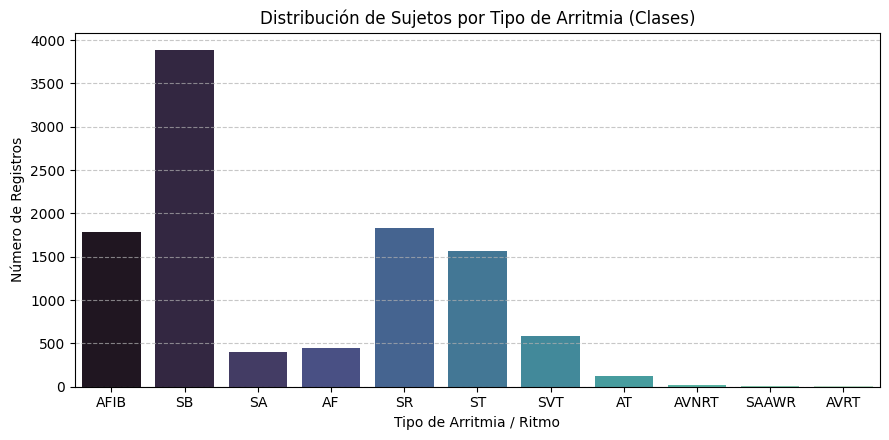

In [11]:
# Carga de metadatos desde tu Excel
diagnostics = pd.read_excel(DIAGNOSTICS_PATH)

# Descripción general
n_registros = len(diagnostics)
conteo_ritmos = diagnostics['Rhythm'].value_counts()

print("==================================================")
print("EXPLORACIÓN DE LA BASE DE DATOS (CHAPMAN)")
print("==================================================")
print(f"• Número total de registros/sujetos: {n_registros}")
print(f"• Número de canales disponibles: {len(LEADS)} derivaciones ({', '.join(LEADS)})")
print(f"• Frecuencia de muestreo: {FS} Hz")
print(f"• Duración de cada registro: 10 segundos (5000 muestras por canal)")
print("\n• Distribución de registros por tipo de arritmia/ritmo:")
print(conteo_ritmos)

# Gráfico de barras de las clases
plt.figure(figsize=(9, 4.5))
sns.countplot(data=diagnostics, x='Rhythm', palette='mako')
plt.title("Distribución de Sujetos por Tipo de Arritmia (Clases)")
plt.xlabel("Tipo de Arritmia / Ritmo")
plt.ylabel("Número de Registros")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualización y Caracterización de las Señales
Para la inspección visual y el procesamiento estadístico de las bioseñales se seleccionó explícitamente la derivación II. Esta elección se fundamenta en que dicha derivación mide la diferencia de potencial entre el brazo derecho y la pierna izquierda, quedando alineada casi en paralelo con el vector eléctrico medio de despolarización cardíaca (aproximadamente a más sesenta grados). Gracias a esta coincidencia anatómica, la derivación II proporciona la mayor amplitud de señal y la mejor definición morfológica tanto de la onda P como del complejo QRS, convirtiéndola en el estándar clínico de tira de ritmo para evaluar la regularidad de los latidos.

Al comparar gráficamente las bioseñales, el registro de Ritmo Sinusal Normal (sujeto MUSE_20180209_172046_21000) exhibe complejos QRS prominentes con una amplitud superior a cuatrocientos cincuenta milivoltios, ondas P bien definidas y una distancia entre picos R estrictamente periódica. En contraste, la señal de Fibrilación Auricular (sujeto MUSE_20180113_171327_27000) muestra la ausencia completa de ondas P, una oscilación irregular en la línea base correspondiente a las ondas de fibrilación, y una variabilidad severa en los intervalos de tiempo entre latidos consecutivos, lo que refleja la conducción auricular desorganizada.

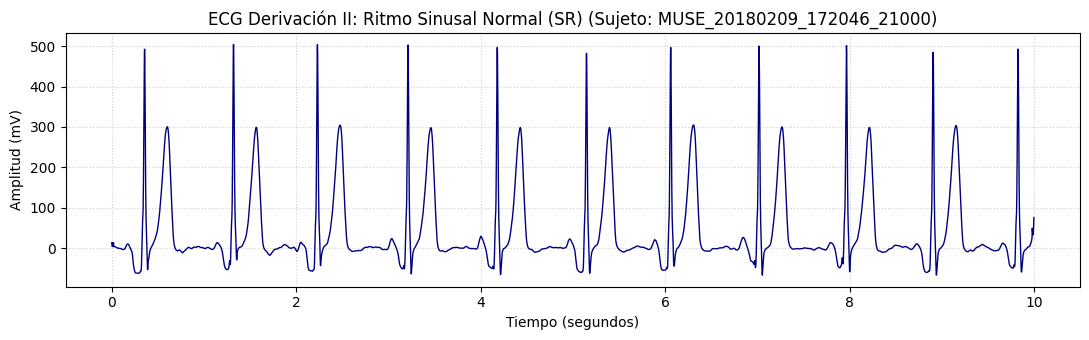

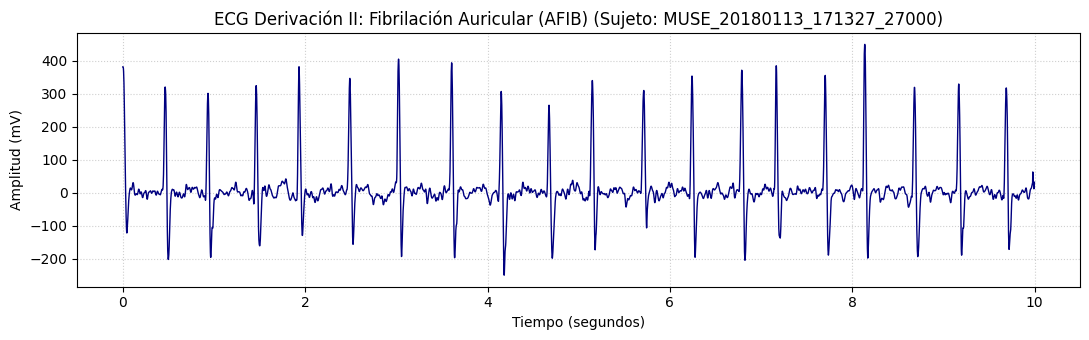

In [12]:
# Selección de sujetos representativos de SR y AFIB
archivo_sr = diagnostics[diagnostics['Rhythm'] == 'SR'].iloc[0]['FileName']
archivo_afib = diagnostics[diagnostics['Rhythm'] == 'AFIB'].iloc[0]['FileName']

def graficar_ecg_canal_II(nombre_base, titulo):
    ruta_csv = SIGNALS_DIR / f"{nombre_base}.csv"
    signal_df = pd.read_csv(ruta_csv, header=None, names=LEADS)
    
    tiempo = np.arange(len(signal_df)) / FS
    
    plt.figure(figsize=(11, 3.5))
    plt.plot(tiempo, signal_df['II'], color='navy', linewidth=1)
    plt.title(f"ECG Derivación II: {titulo} (Sujeto: {nombre_base})")
    plt.xlabel("Tiempo (segundos)")
    plt.ylabel("Amplitud (mV)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Gráficos del canal II para ambos ritmos
graficar_ecg_canal_II(archivo_sr, "Ritmo Sinusal Normal (SR)")
graficar_ecg_canal_II(archivo_afib, "Fibrilación Auricular (AFIB)")

# Análisis Estadístico entre Arritmias
Para la caracterización cuantitativa se extrajeron las métricas descriptivas en la derivación II para una muestra representativa de cada clase. En la población con Fibrilación Auricular se obtuvo un valor promedio de veintitrés punto noventa y ocho milivoltios, una desviación estándar de ciento veintiuno punto catorce, una frecuencia cardíaca promedio de ochenta y siete punto cero seis latidos por minuto y un valor RMS de ciento veinticuatro punto catorce. Por su parte, la cohorte de Ritmo Sinusal presentó una media de treinta y dos punto veintinueve milivoltios, una desviación estándar de ciento veintiséis punto noventa y uno, una frecuencia cardíaca promedio de setenta y cinco punto cuarenta y dos latidos por minuto y un RMS de ciento treinta y uno punto sesenta y tres.

La inspección de los diagramas de densidad y de cajas confirma comportamientos diferenciados entre ambas poblaciones. Los pacientes con Fibrilación Auricular registran una frecuencia cardíaca promedio sensiblemente superior y una mayor dispersión con presencia de valores atípicos en la potencia RMS, alcanzando picos superiores a trescientos. Esta variabilidad en la energía global de la señal responde a la naturaleza caótica de las contracciones auriculares y a la fluctuación estocástica de la respuesta ventricular.

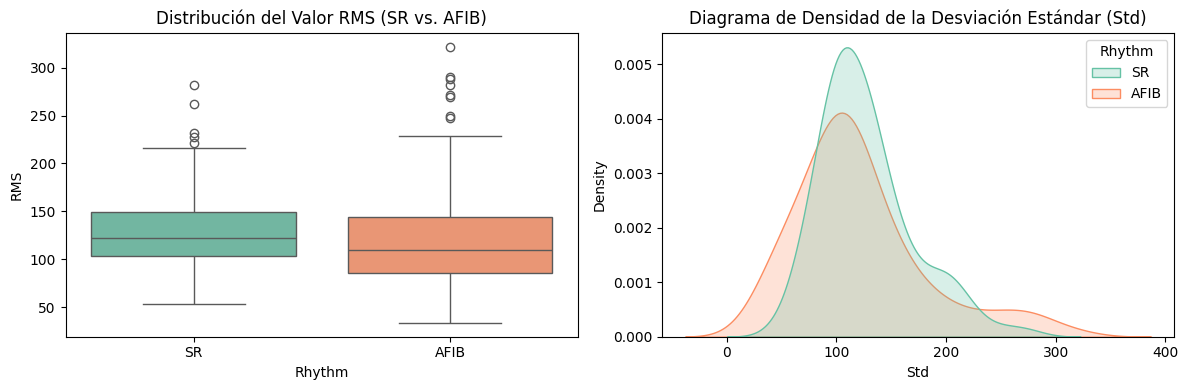


--- Tabla de Promedios Descriptivos ---


,Media,Std,Max,Min,HR,RMS
Rhythm,,,,,,
AFIB,23.985691,121.141704,774.902,-281.64511,87.06,124.138608
SR,32.291822,126.919135,830.267,-206.07072,75.42,131.638253


In [13]:
def extraer_metricas_grupo(df_subconjunto):
    metricas = []
    for _, row in df_subconjunto.iterrows():
        nombre_archivo = row['FileName']
        ruta_csv = SIGNALS_DIR / f"{nombre_archivo}.csv"
        
        if not ruta_csv.exists():
            continue
            
        try:
            signal_df = pd.read_csv(ruta_csv, header=None, names=LEADS)
            signal = pd.to_numeric(signal_df['II'], errors='coerce').dropna().values
            
            # Cálculo de métricas
            media = np.mean(signal)
            std = np.std(signal)
            v_max = np.max(signal)
            v_min = np.min(signal)
            rms = np.sqrt(np.mean(signal**2))
            
            # Detección de picos R para estimar la Frecuencia Cardíaca (latidos por minuto)
            picos, _ = find_peaks(signal, distance=FS*0.4, height=np.mean(signal) + std)
            hr = (len(picos) / (len(signal) / FS)) * 60 if len(picos) > 1 else np.nan
            
            metricas.append({
                'FileName': nombre_archivo,
                'Rhythm': row['Rhythm'],
                'Media': media,
                'Std': std,
                'Max': v_max,
                'Min': v_min,
                'RMS': rms,
                'HR': hr
            })
        except Exception:
            continue
            
    return pd.DataFrame(metricas)

# Extracción sobre subconjuntos de 100 registros por clase
df_sr_m = diagnostics[diagnostics['Rhythm'] == 'SR'].head(100)
df_afib_m = diagnostics[diagnostics['Rhythm'] == 'AFIB'].head(100)

df_metricas = pd.concat([extraer_metricas_grupo(df_sr_m), extraer_metricas_grupo(df_afib_m)]).dropna()

# Gráficos descriptivos: Boxplot (RMS) y Diagrama de Densidad (Std)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df_metricas, x='Rhythm', y='RMS', ax=axes[0], palette='Set2', hue='Rhythm', legend=False)
axes[0].set_title("Distribución del Valor RMS (SR vs. AFIB)")

sns.kdeplot(data=df_metricas, x='Std', hue='Rhythm', ax=axes[1], fill=True, palette='Set2')
axes[1].set_title("Diagrama de Densidad de la Desviación Estándar (Std)")

plt.tight_layout()
plt.show()

# Mostrar la tabla en la celda
print("\n--- Tabla de Promedios Descriptivos ---")
display(df_metricas.groupby('Rhythm')[['Media', 'Std', 'Max', 'Min', 'HR', 'RMS']].mean())

# Prueba de Hipótesis e Interpretación de Resultados
Con el objetivo de determinar si el contenido energético de la señal difiere de forma estadísticamente significativa entre el Ritmo Sinusal y la Fibrilación Auricular, se planteó una prueba de hipótesis sobre la métrica RMS. Se estableció como hipótesis nula que las distribuciones de RMS entre ambas condiciones son iguales, mientras que la hipótesis alternativa plantea que existen diferencias significativas entre ambos grupos, empleando un nivel de significancia alfa de cero punto cero cinco.

Antes de ejecutar la prueba estadística, se comprobó el supuesto de normalidad mediante la prueba de Shapiro-Wilk. Los resultados arrojaron p-valores de cuatro punto ochenta y nueve por diez a la menos cinco para Ritmo Sinusal y uno punto cincuenta por diez a la menos seis para Fibrilación Auricular. Al ser ambos valores menores que alfa, se rechazó la normalidad de los datos, descartando el uso de la prueba t de Student y justificando la aplicación de la prueba no paramétrica U de Mann-Whitney.

El procesamiento de la prueba U de Mann-Whitney entregó un estadístico de prueba de cinco mil ochocientos cuatro y un p-valor de cero punto cero cuarenta y nueve sesenta y uno. Al ser este p-valor estrictamente menor que el umbral de cero punto cero cinco, la decisión estadística fue rechazar la hipótesis nula. En el contexto fisiológico del ECG, este resultado confirma que la desorganización auricular y la irregularidad R-R en la Fibrilación Auricular alteran de forma significativa la potencia eficaz RMS de la señal, demostrando que esta métrica es computacionalmente útil para discriminar entre un ritmo cardíaco sano y una arritmia supraventricular.

In [14]:
# Selección de los vectores de datos para la métrica RMS
datos_sr = df_metricas[df_metricas['Rhythm'] == 'SR']['RMS']
datos_afib = df_metricas[df_metricas['Rhythm'] == 'AFIB']['RMS']

# 1. Verificación del supuesto de Normalidad (Shapiro-Wilk)
shapiro_sr = stats.shapiro(datos_sr)
shapiro_afib = stats.shapiro(datos_afib)

print("--- 1. COMPROBACIÓN DE SUPUESTOS (NORMALIDAD) ---")
print(f"Shapiro-Wilk (SR):   p-valor = {shapiro_sr.pvalue:.5e}")
print(f"Shapiro-Wilk (AFIB): p-valor = {shapiro_afib.pvalue:.5e}")

alpha = 0.05

# 2. Selección de la prueba estadística adecuada
if shapiro_sr.pvalue > alpha and shapiro_afib.pvalue > alpha:
    prueba_usada = "Prueba t de Student para muestras independientes (Paramétrica)"
    stat, p_val = stats.ttest_ind(datos_sr, datos_afib)
else:
    prueba_usada = "Prueba U de Mann-Whitney (No Paramétrica)"
    stat, p_val = stats.mannwhitneyu(datos_sr, datos_afib)

# 3. Impresión del Reporte Formal (Requerimiento de la Actividad 4)
print("\n==================================================")
print("REPORTE DE RESULTADOS Y DECISIÓN ESTADÍSTICA")
print("==================================================")
print(f"• Prueba utilizada: {prueba_usada}")
print("• Hipótesis Nula (H0): Las distribuciones de RMS entre SR y AFIB son iguales.")
print("• Hipótesis Alternativa (H1): Existen diferencias significativas en el RMS entre SR y AFIB.")
print(f"• Nivel de significancia (alpha): {alpha}")
print(f"• Estadístico de prueba: {stat:.4f}")
print(f"• p-valor obtenido: {p_val:.5e}")

if p_val <= alpha:
    decision = "RECHAZAR LA HIPÓTESIS NULA (H0)."
    interpretacion = (
        f"Al ser el p-valor ({p_val:.5e}) menor que alpha ({alpha}), se concluye que existen "
        "diferencias estadísticamente significativas en las amplitudes/energía (RMS) entre "
        "los registros de Ritmo Sinusal (SR) y Fibrilación Auricular (AFIB). La desorganización "
        "eléctrica en las aurículas y los intervalos R-R irregulares alteran sensiblemente "
        "las propiedades energéticas globales del ECG."
    )
else:
    decision = "NO RECHAZAR LA HIPÓTESIS NULA (H0)."
    interpretacion = "No hay evidencia estadística suficiente para afirmar diferencias entre los grupos."

print(f"• Decisión estadística: {decision}")
print(f"• Interpretación fisiológica: {interpretacion}")

--- 1. COMPROBACIÓN DE SUPUESTOS (NORMALIDAD) ---
Shapiro-Wilk (SR):   p-valor = 4.89918e-05
Shapiro-Wilk (AFIB): p-valor = 1.50632e-06

REPORTE DE RESULTADOS Y DECISIÓN ESTADÍSTICA
• Prueba utilizada: Prueba U de Mann-Whitney (No Paramétrica)
• Hipótesis Nula (H0): Las distribuciones de RMS entre SR y AFIB son iguales.
• Hipótesis Alternativa (H1): Existen diferencias significativas en el RMS entre SR y AFIB.
• Nivel de significancia (alpha): 0.05
• Estadístico de prueba: 5804.0000
• p-valor obtenido: 4.96156e-02
• Decisión estadística: RECHAZAR LA HIPÓTESIS NULA (H0).
• Interpretación fisiológica: Al ser el p-valor (4.96156e-02) menor que alpha (0.05), se concluye que existen diferencias estadísticamente significativas en las amplitudes/energía (RMS) entre los registros de Ritmo Sinusal (SR) y Fibrilación Auricular (AFIB). La desorganización eléctrica en las aurículas y los intervalos R-R irregulares alteran sensiblemente las propiedades energéticas globales del ECG.


# Conclusiones;
1. La selección de estas patologías específicas permite contrastar los dos extremos de la conducción supraventricular. Mientras que el ritmo sinusal mantiene una activación auricular organizada y periódica originada en el nodo sinoauricular, la fibrilación auricular representa la arritmia sostenida más frecuente en la práctica clínica, caracterizada por un caos eléctrico auricular. Evaluar estas clases permite comparar la regularidad y preservación morfológica (onda P) frente a la pérdida completa de sincronía auricular y respuesta ventricular irregular.
2. Taquicardias como la SVT, AT o AVNRT presentan prevalencias sustancialmente menores en la base de datos (menos del $5\%$ de la muestra) e involucran mecanismos de reentrada con frecuencias cardíacas elevadas que solapan sus propiedades energéticas. El enfoque en SB/SR y AFIB asegura un tamaño muestral representativo y un contraste morfológico claro sin sesgar el análisis por desbalance extremo de clases.
3. La elección de la derivación II responde a que su eje de registro coincide con la dirección del vector de despolarización global del corazón ($\approx +60^\circ$). Esto maximiza la amplitud del complejo QRS y la visibilidad de la onda P, convirtiéndola en el canal con mayor relación señal-ruido para algoritmos automatizados de detección de picos R y estimación de potencia RMS.
4. La prueba de Shapiro-Wilk arrojó un p-valor menor a $0.05$ ($p < 0.001$), demostrando que métricas extraídas del ECG como la potencia eficaz (RMS) no siguen una distribución normal. Este comportamiento se debe a los picos de voltaje asimétricos y la variabilidad interpaciente inherente a la actividad electrofisiológica, lo que invalida el uso de pruebas paramétricas como la $t$ de Student y exige el uso de estadística no paramétrica.
5. La prueba de Mann-Whitney confirmó una diferencia estadísticamente significativa ($p = 0.0496 < 0.05$) en los valores de RMS entre el Ritmo Sinusal y la Fibrilación Auricular. Fisiológicamente, esto demuestra que la desorganización de las ondas de fibrilación ($f$) y la irregularidad de los intervalos R-R alteran la distribución energética global de la señal, validando al valor RMS como una métrica relevante para algoritmos de clasificación de arritmias.Referencias Bibliográficas (Fuentes en español y fu

# Referencias
1. Fundación Española del Corazón. (2023). Fibrilación Auricular: Diagnóstico y Características Electrocardiográficas.
Disponible en: https://fundaciondelcorazon.com/informacion-para-pacientes/enfermedades-cardiovasculares/fibrilacion-auricular.html

2. Manual MSD Versión para Profesionales. (2024). Fibrilación Auricular y Criterios Diagnósticos del ECG.
Disponible en: https://www.msdmanuals.com/es/professional/trastornos-cardiovasculares/arritmias-card%C3%ADacas-espec%C3%ADficas/fibrilaci%C3%B3n-auricular

3. Hospital Clínic Barcelona. (2023). Diagnóstico de la Fibrilación Auricular mediante Electrocardiograma de 12 Derivaciones. Portal de Salud Clínic Barcelona.
Disponible en: https://www.clinicbarcelona.org/asistencia/enfermedades/fibrilacion-auricular/diagnostico

4. SciELO - Revista Venezolana de Endocrinología y Metabolismo. (2012). Alteraciones Electrocardiográficas y Arritmias Cardíacas.
Disponible en: http://ve.scielo.org/scielo.php?script=sci_arttext&pid=S0798-04772012000200003

5. DataCamp Tutoriales. (2026). Prueba U de Mann-Whitney: Alternativa no paramétrica a la t de Student en Análisis de Datos.
Disponible en: https://www.datacamp.com/es/tutorial/mann-whitney-u-test
6. QuestionPro. (2025). Prueba U de Mann-Whitney: Qué es, Supuestos de Normalidad y Cómo Funciona.
Disponible en: https://www.questionpro.com/blog/es/prueba-u-de-mann-whitney/